# §1 Individual (unfiltered) (v12) — net of costs

Per-combo metrics and per-combo equity/drawdown curves on the
20% OOS test partition with no ML#2 filter. Two sizing policies
compared: `fixed_dollars_500` and `pct5_compound`.

**Cost model:** every trade is charged `contracts × $5.00` round-trip (≈ $3 retail commission + 2 ticks/side slippage on MNQ at $0.50/tick). Applied to both sizing policies.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, RISK_FRAC, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=5.0, top_strategies_path=REPO / 'evaluation' / 'top_strategies_v12.json')
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Top-K source: top_strategies_v12.json


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Applying friction: $5.00/contract RT (commission + slippage).
Loaded 10 strategies.
Loaded results_raw from cache (10 combos).
Combined unfiltered trades: 4,537


Loaded combos_ml2 from cache (10 combos).
ML2 portfolio trade counts: {'fixed_dollars_500': 0, 'pct5_compound': 0}


In [2]:
rows = []
for r in results_raw:
    if r['trades'].empty:
        for policy in POLICIES:
            rows.append({'combo_id': r['combo_id'], 'policy': policy,
                         **metrics_from_pnl(np.array([]), YEARS_SPAN, policy=policy)})
        continue
    t = r['trades'].sort_values('date', kind='mergesort')
    pnl_base = t['actual_pnl'].to_numpy(dtype=float)
    risk_base = t['dollar_risk'].to_numpy(dtype=float)
    r_mult = np.where(risk_base > 0, pnl_base / risk_base, 0.0)
    for policy in POLICIES:
        pnl = apply_sizing(pnl_base, risk_base, policy)
        rows.append({'combo_id': r['combo_id'], 'policy': policy,
                     **metrics_from_pnl(pnl, YEARS_SPAN, policy=policy, r=r_mult)})
perf1 = pd.DataFrame(rows)
perf1

,combo_id,policy,n_trades,trades_per_year,win_rate,total_pnl_dollars,total_return_pct,sharpe_ratio,max_drawdown_pct,max_drawdown_dollars
0,v11_2646,fixed_dollars_500,294,201.2,0.1667,-16668.96,-33.34,-1.5449,40.63,20674.91
1,v11_2646,pct5_compound,294,201.2,0.1667,-46599.11,-93.20,-2.0621,94.49,50589.39
2,v11_391,fixed_dollars_500,178,121.8,0.2809,161.24,0.32,0.0154,20.57,11391.50
3,v11_391,pct5_compound,178,121.8,0.2809,-21887.93,-43.78,-0.4416,80.15,67696.44
4,v11_28651,fixed_dollars_500,1155,790.5,0.3030,22812.11,45.62,0.6439,37.43,28676.82
5,v11_28651,pct5_compound,1155,790.5,0.3030,-42832.88,-85.67,-0.5569,99.45,331656.25
6,v11_17782,fixed_dollars_500,401,274.5,0.3167,7362.70,14.73,0.4335,21.41,14269.19
7,v11_17782,pct5_compound,401,274.5,0.3167,-15481.56,-30.96,-0.1996,89.12,175175.73
8,v11_263,fixed_dollars_500,482,329.9,0.3444,-25216.70,-50.43,-1.6131,56.95,30222.69
9,v11_263,pct5_compound,482,329.9,0.3444,-48803.77,-97.61,-2.2215,98.30,59454.94


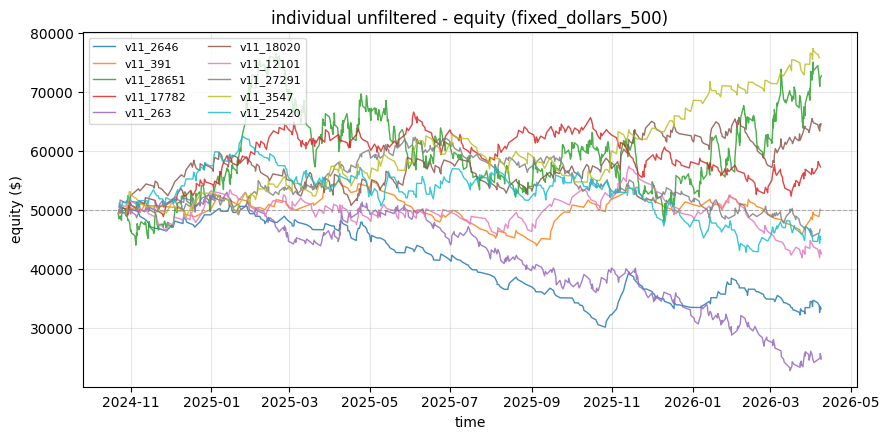

In [3]:
plot_indiv_equity(results_raw, 'fixed_dollars_500')

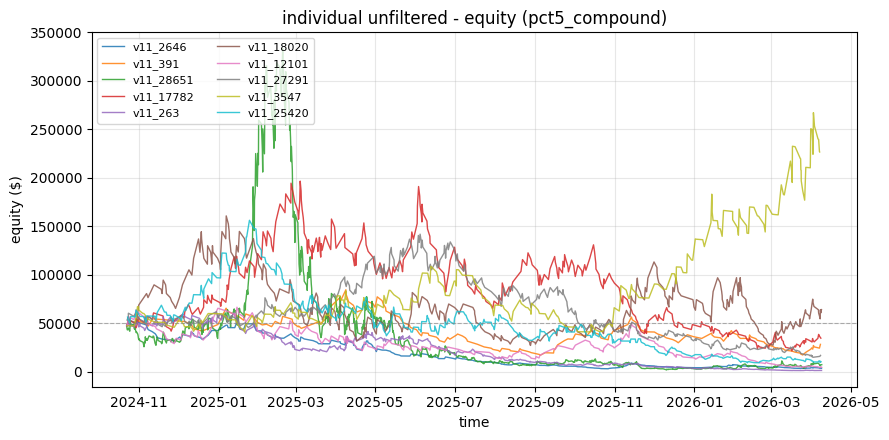

In [4]:
plot_indiv_equity(results_raw, 'pct5_compound')

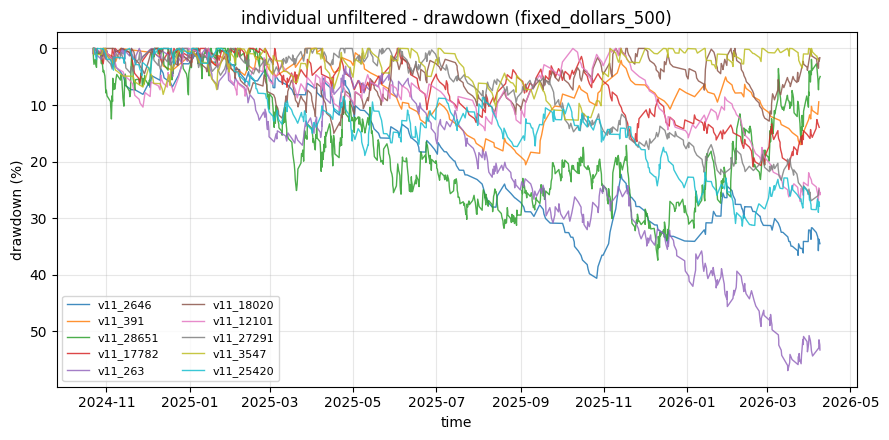

In [5]:
plot_indiv_dd(results_raw, 'fixed_dollars_500')

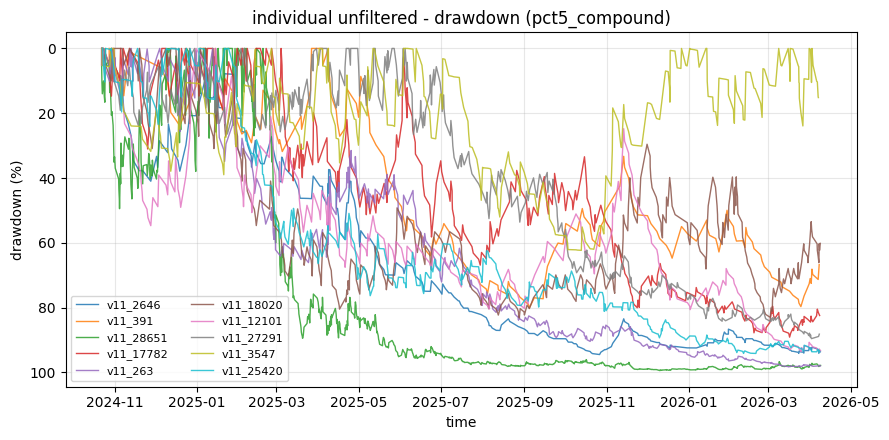

In [6]:
plot_indiv_dd(results_raw, 'pct5_compound')